This notebook runs first.
After that run notebook test_kafka_producer_consumer.ipynb

In [1]:

!pip3 install lxml  

!pip3 install bs4  


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 3.2 MB/s eta 0:00:0000:0100:01m

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


## Prerequisite

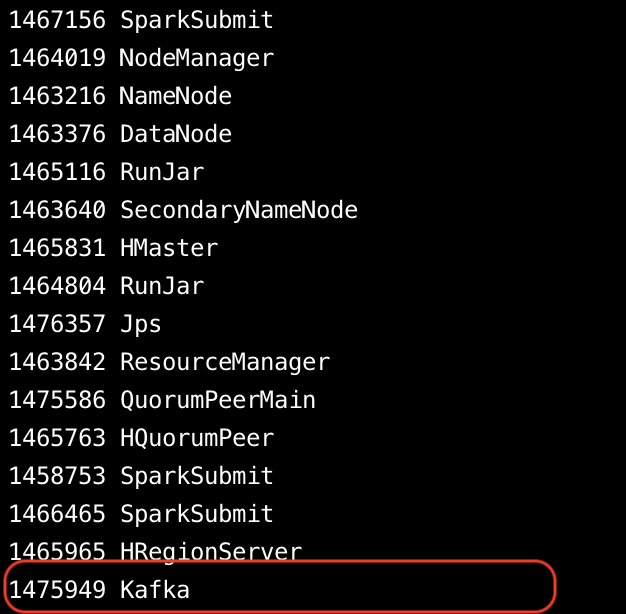



`bin/zookeeper-server-start.sh config/zookeeper.properties`

<br>

`bin/kafka-server-start.sh config/server.properties`

In [2]:
from __future__ import unicode_literals

import json
from time import sleep
from bs4 import BeautifulSoup

In [3]:
from kafka import KafkaConsumer, KafkaProducer

import requests
# -*- coding: utf-8 -*-


In [16]:
def fetch_raw(recipe_url):
    html = None
    print('Processing..{}'.format(recipe_url))
    try:
        r = requests.get(recipe_url, headers=headers)
        if r.status_code == 200:
            html = r.text
             
    except Exception as ex:
        print('Exception while accessing raw html')
        print(str(ex))
    finally:
        return html.strip()

def get_recipes(url):
    recipes = []
    print('Accessing list')

    try:
        r = requests.get(url, headers=headers)
         
        if r.status_code == 200:
            soup = BeautifulSoup(r.text, 'html.parser')
            print(r.text)

            # TODO
            # loop to each receipe header
            # get the link 
            # traverse to subpage, send raw data
            # limit to 10 link
            
            

    except Exception as ex:
        print('Exception in get_recipes:', str(ex))
    
    return recipes

In [17]:
def publish_message(producer_instance, topic_name, key, value):
    try:
        #print(key)
        #print(value)
        key_bytes =  bytes(key, encoding='utf-8')   #.encode('utf-8')
        value_bytes = bytes(value, encoding='utf-8') #encode('utf-8')
        
        producer_instance.send(topic_name, key=key_bytes, value=value_bytes)
        #print(value_bytes)
        producer_instance.flush()
        print('Message published successfully.')
    except Exception as ex:
        print('Exception in publishing message')
        print(str(ex))


def connect_kafka_producer():
    _producer = None
    try:
        _producer = KafkaProducer(bootstrap_servers=['localhost:9092'], api_version=(0, 10))
    except Exception as ex:
        print('Exception while connecting Kafka')
        print(str(ex))
    finally:
        return _producer

In [18]:
if __name__ == '__main__':
    headers = {
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/66.0.3359.181 Safari/537.36',
        'Pragma': 'no-cache'
    }
    
    url = 'https://www.wongnai.com/recipes'
    all_recipes = get_recipes(url)
    print( all_recipes )
    
     
    if len(all_recipes) > 0:
        kafka_producer = connect_kafka_producer()
        for count, recipe in enumerate(all_recipes, start=1):
             
            publish_message(kafka_producer, 'raw_recipes', 'raw', recipe.strip())
            if count > 3:
                break
        if kafka_producer is not None:
            kafka_producer.close()

Accessing list
<!DOCTYPE html>
<html xmlns:fb="http://ogp.me/ns/fb#" xmlns:og="http://ogp.me/ns#" lang="th">
<head>
	<title data-react-helmet="true">รวมเมนูอาหารล่าสุด สูตรอาหาร วิธีทำอาหาร</title>
	<meta data-react-helmet="true" name="description" content="รวมเมนูอาหาร สูตรอาหารล่าสุด พร้อมรูปภาพ วิดิโอและวิธีทำอย่างละเอียด ไม่ว่าจะเป็น อาหารไทย อาหารลดน้ำหนัก อาหารอีสาน เมนูไมโครเวฟ และ อื่นๆ"/><meta data-react-helmet="true" name="keywords" content="เมนูอาหารล่าสุด, สูตรอาหารล่าสุด,วิธีทำอาหาร,wongnai,cooking,วงใน"/><meta data-react-helmet="true" name="robots" content="all"/><meta data-react-helmet="true" property="og:title" content="รวมเมนูอาหารล่าสุด สูตรอาหาร วิธีทำอาหาร on wongnai.com"/><meta data-react-helmet="true" property="og:type" content="article"/><meta data-react-helmet="true" property="og:url" content="https://www.wongnai.com/recipes"/><meta data-react-helmet="true" property="og:description" content="รวมเมนูอาหาร สูตรอาหารล่าสุด พร้อมรูปภาพ วิดิโอและวิธีทำอย่างละเอียด ไม

At this point, your jps should have

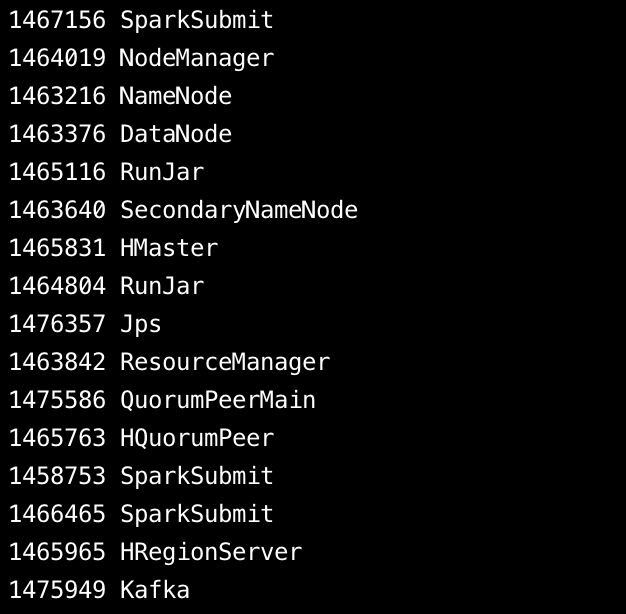